# Step 4 — Segmentation

k-means on six features (recency, frequency, monetary, spend per invoice, items per invoice, and a product-variety ratio), log-transformed where skewed and standardised. The model finds natural groupings; we then profile and name each one. This is the centrepiece of the project.

In [1]:
# Setup: run from the project root so the data directory and results/
# resolve exactly as they do in main.py, and the step modules import.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import pandas as pd
from IPython.display import Image, display

DATA_DIR = "kaggle_customer_intelligence"


In [2]:
# Small loaders for the artefacts the earlier steps saved.
def load_sales():
    p = f"{DATA_DIR}/clean_sales.parquet"
    try:
        return pd.read_parquet(p)
    except Exception:
        df = pd.read_csv(f"{DATA_DIR}/clean_sales.csv", parse_dates=["InvoiceDate"])
        df["CustomerID"] = df["CustomerID"].astype("Int64")
        return df

def load_customer_sales():
    s = load_sales()
    return s[s["CustomerID"].notna()].reset_index(drop=True)


In [11]:
from retail_segmentation import CustomerSegmenter

rfm_features = pd.read_parquet(f"{DATA_DIR}/rfm_features.parquet")
customer_sales = load_customer_sales()

seg = CustomerSegmenter(rfm_features, customer_sales)
seg.run()   # builds features, transforms, heatmap, elbow + silhouette

SEGMENTATION
Built features for 5,852 customers.
Logged skewed features and standardised all six to z-scores.
Saved correlation heatmap (check the variety fix worked).
  k= 2  inertia=      24,304  silhouette=0.270
  k= 3  inertia=      19,627  silhouette=0.239
  k= 4  inertia=      17,247  silhouette=0.223
  k= 5  inertia=      14,971  silhouette=0.228
  k= 6  inertia=      13,831  silhouette=0.204
  k= 7  inertia=      12,839  silhouette=0.202
  k= 8  inertia=      11,987  silhouette=0.204
  k= 9  inertia=      11,299  silhouette=0.198
  k=10  inertia=      10,757  silhouette=0.200
  k=11  inertia=      10,262  silhouette=0.201
  k=12  inertia=       9,831  silhouette=0.195
  k=13  inertia=       9,461  silhouette=0.191
  k=14  inertia=       9,162  silhouette=0.189
  k=15  inertia=       8,831  silhouette=0.188

Review the elbow and silhouette charts, then call .fit(k).profile().label_clusters().plot_pca().plot_umap().save() with your chosen k.

Saved figures to results\segmentation

### Are the features independent?

k-means treats every axis as independent, so correlated features get counted twice. Frequency and monetary correlate strongly (~0.85), as do the two basket measures (~0.83). The **variety ratio came out close to independent** of everything, which is what we engineered it to do, so it pulls its own weight rather than echoing the basket size.

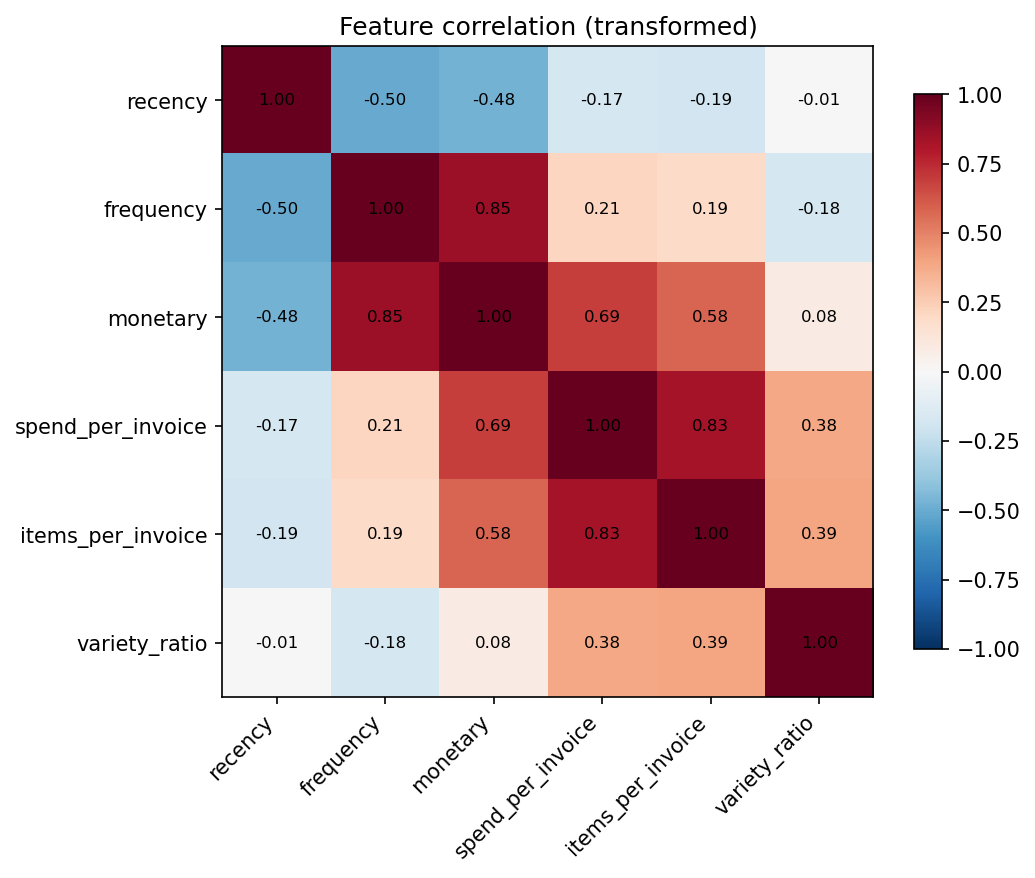

In [5]:
display(Image(filename="results/segmentation/figures/feature_correlation.png"))

### Choosing k

The elbow bends around k=5 and the silhouette is modest everywhere (~0.20–0.23), because the correlated features make the clusters overlap. Comparing the profiles at k=5, 6 and 7, **k=6 earns its keep**: going from 5 to 6 splits the high-value core into two genuinely different groups (the frequent reorderers and the big-basket buyers), while 7 only cuts a middle group into near-duplicates.

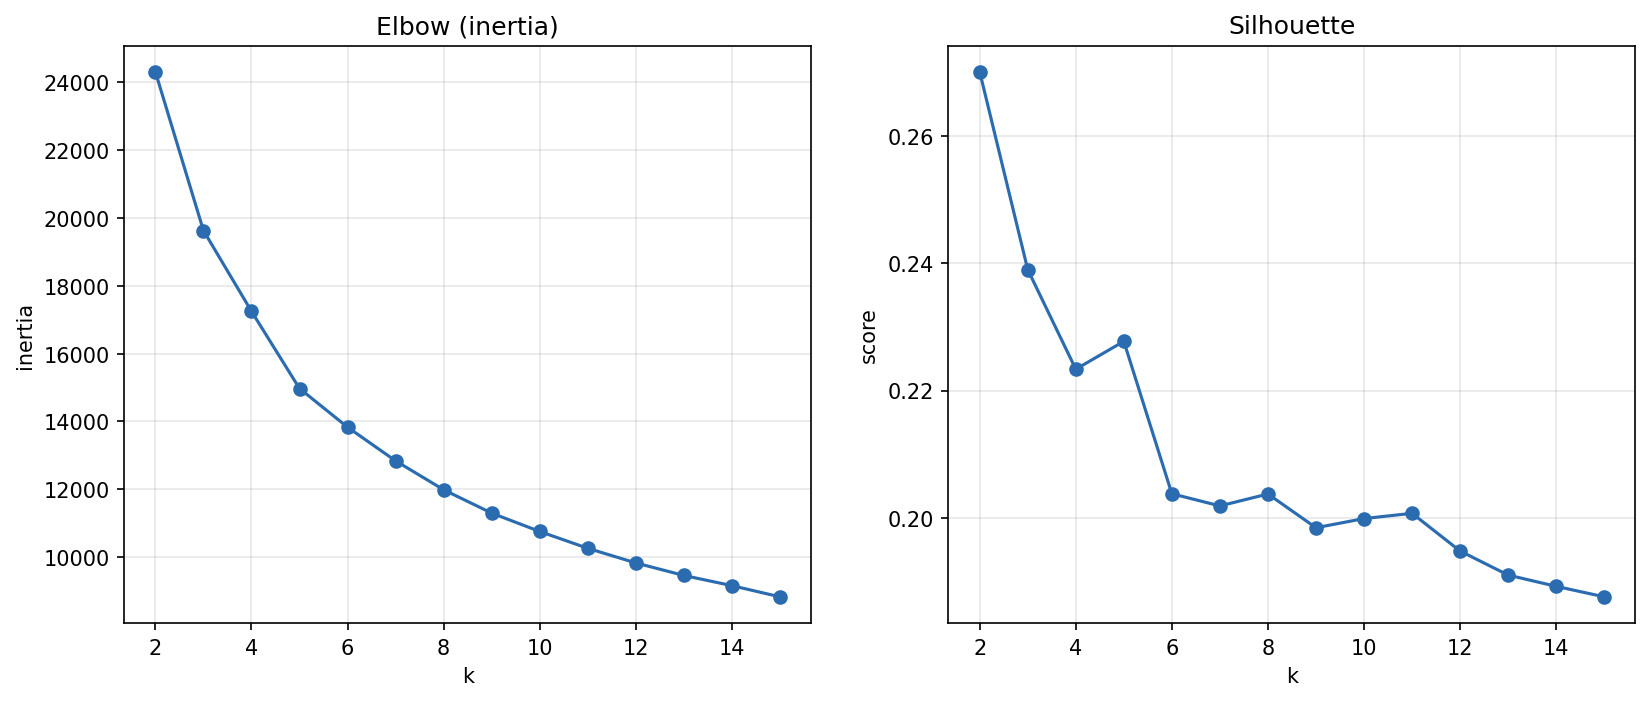

In [6]:
display(Image(filename="results/segmentation/figures/k_search.png"))

In [7]:
seg.fit(6).profile().label_clusters()
seg.save(DATA_DIR)

Fitted k-means with k=6.

Cluster profile (raw averages):
         customers  recency  frequency  monetary  spend_per_invoice  items_per_invoice  variety_ratio  pct_customers  uk_share     top_country
cluster                                                                                                                                       
0             1020   149.39       3.31   2155.66             720.58             591.74          34.51           17.4      0.81  United Kingdom
1             1272    86.51       8.37   2063.73             263.76             150.82          11.94           21.7      0.94  United Kingdom
2             1086    91.95       2.22    463.58             221.74             135.44          17.77           18.6      0.93  United Kingdom
3             1175   490.17       1.72    465.36             277.21             164.50          20.53           20.1      0.93  United Kingdom
4              679    42.49      24.85  15940.08             648.12             385.

### The six segments

Read from the profile table (average raw values per cluster):

- **Champions** — frequent (~25 orders), recent, high spend (~£16k), narrow range. The core revenue.
- **Big-basket bulk buyers** — occasional but huge mixed baskets, the most international group (UK share ~0.81). Overseas distributors.
- **Frequent regulars** — fairly recent, ~8 orders, ~£2k, narrow range. The loyal mid-value backbone.
- **Occasional low-value** — still active, few orders, low spend. Light shoppers worth nudging.
- **Lapsed one-off buyers** — last seen over a year ago, bought once or twice. (Their variety ratio looks high, but that's just their single basket, not real range.)
- **Dormant / lost** — a year-plus dormant, tiny baskets, lowest value.

In [8]:
pd.read_csv("results/segmentation/tables/cluster_profile.csv", index_col=0)

,customers,recency,frequency,monetary,spend_per_invoice,items_per_invoice,variety_ratio,pct_customers,uk_share,top_country
cluster,,,,,,,,,,
0,1020,149.39,3.31,2155.66,720.58,591.74,34.51,17.4,0.81,United Kingdom
1,1272,86.51,8.37,2063.73,263.76,150.82,11.94,21.7,0.94,United Kingdom
2,1086,91.95,2.22,463.58,221.74,135.44,17.77,18.6,0.93,United Kingdom
3,1175,490.17,1.72,465.36,277.21,164.50,20.53,20.1,0.93,United Kingdom
4,679,42.49,24.85,15940.08,648.12,385.05,11.74,11.6,0.90,United Kingdom
5,620,335.51,2.04,202.45,100.80,45.72,4.57,10.6,0.95,United Kingdom


### Where the segments sit (PCA)

PC1 and PC2 hold about **77% of the variance** (50% and 27%), so this flat picture is faithful. PC1 (left to right) is value and activity; PC2 (up) is mostly the variety ratio. The two wholesale types separate cleanly: champions sit far right and low (high value, narrow range), bulk buyers top right (high value, wide range). The gradient from dormant on the left to champions on the right is the customer lifecycle.

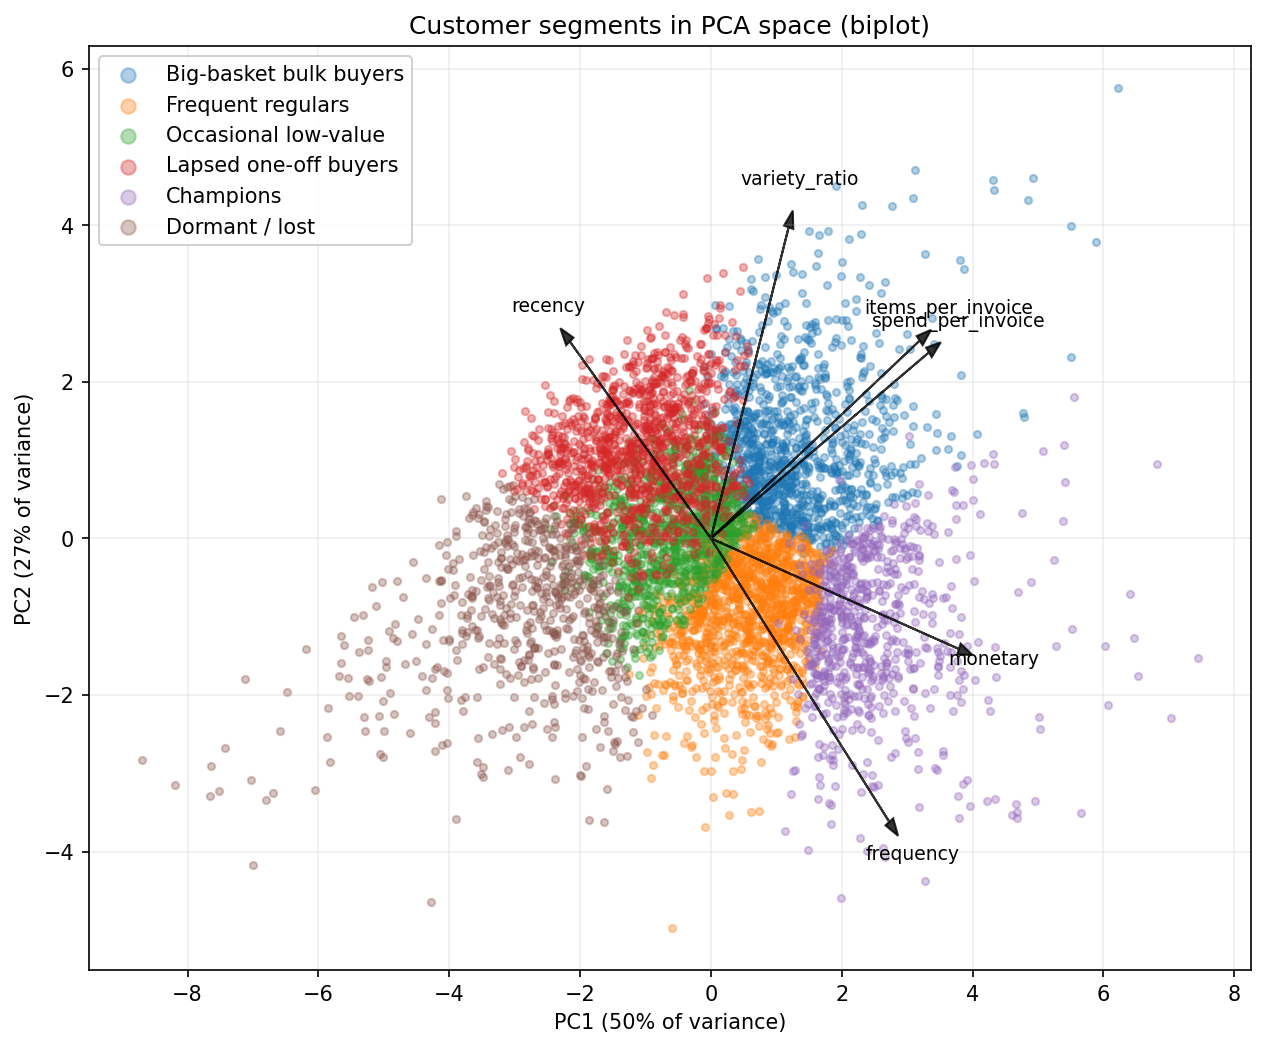

In [9]:
display(Image(filename="results/segmentation/figures/segments_pca.png"))

### Sanity check (UMAP)

UMAP emphasises separation; the distances and layout are not meaningful. The six colours form coherent regions rather than confetti, which is reassurance the k=6 split is real structure. Read it only as "do the groups hold together".

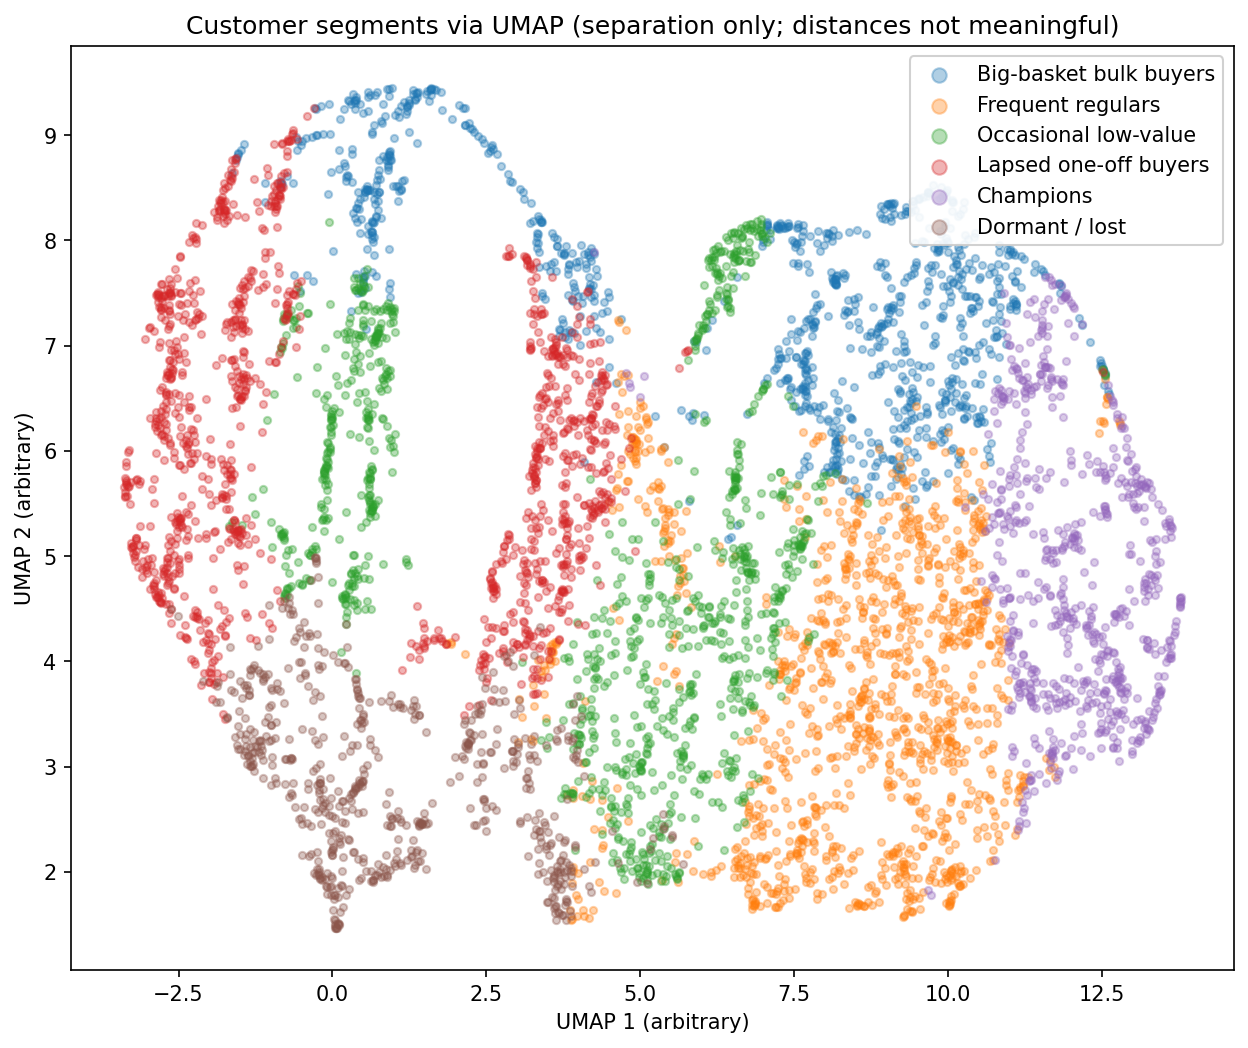

In [10]:
display(Image(filename="results/segmentation/figures/segments_umap.png"))

**Hands off to:** `customer_segments` (saved to the data dir). The wholesaler question is answered with a twist: there are two wholesale types, not one.